Parameter bounds (mean ± 2*std):
  A_alpha: [0.0084, 0.0100] (mean=0.0092)
  V_alpha: [53.4000, 64.6000] (mean=59.0000)
  k_alpha: [3.3000, 10.5000] (mean=6.9000)
  A_beta: [0.0600, 0.0720] (mean=0.0660)
  tau_beta: [73.0000, 127.0000] (mean=100.0000)

Generating 8192 Saltelli samples...


/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_39930/149757819.py:104: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Total parameter sets to simulate: 98304

Running 98304 simulations...

Computing Sobol indices...

Generating plots...


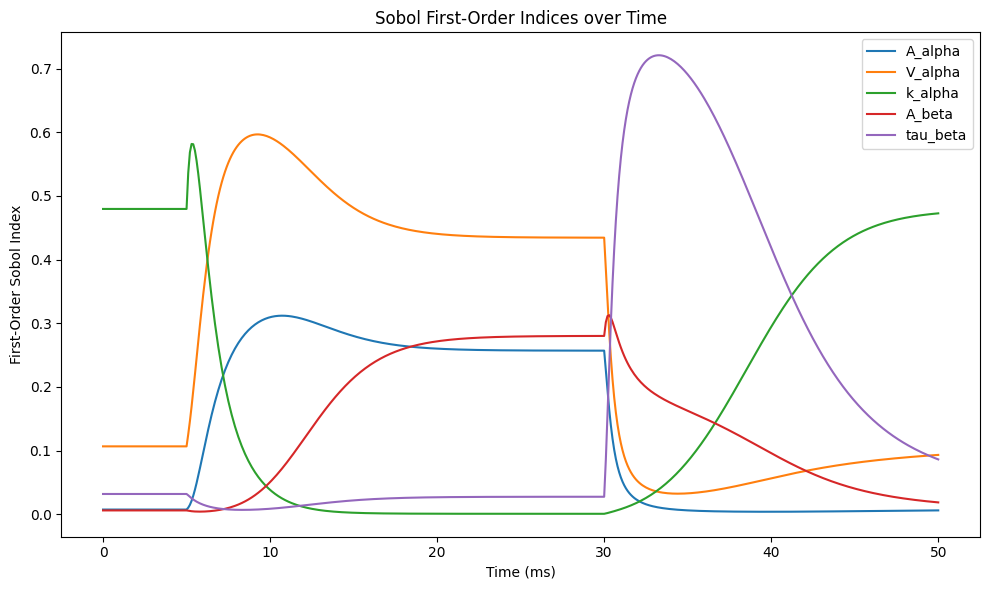

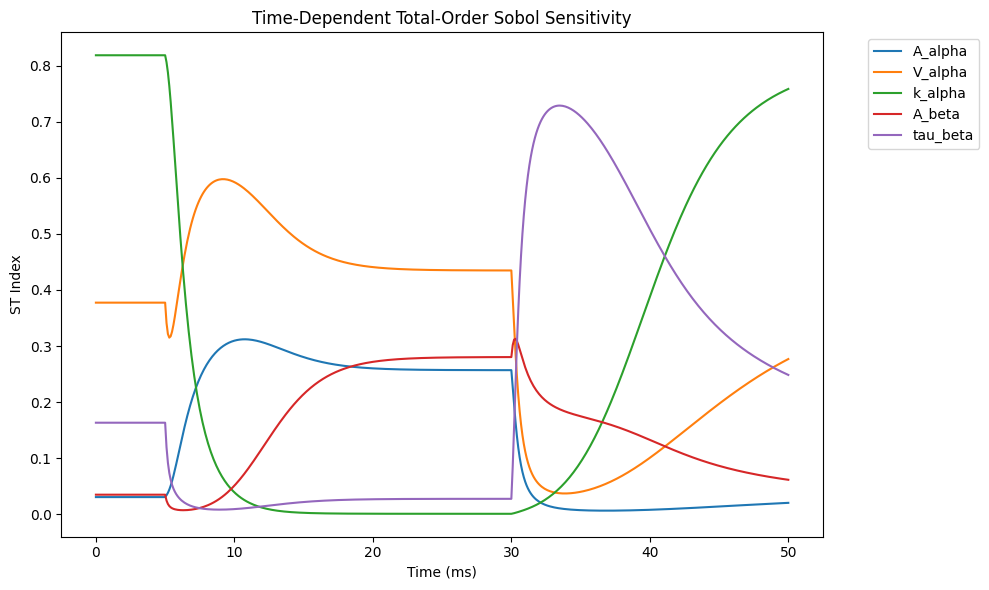

98304


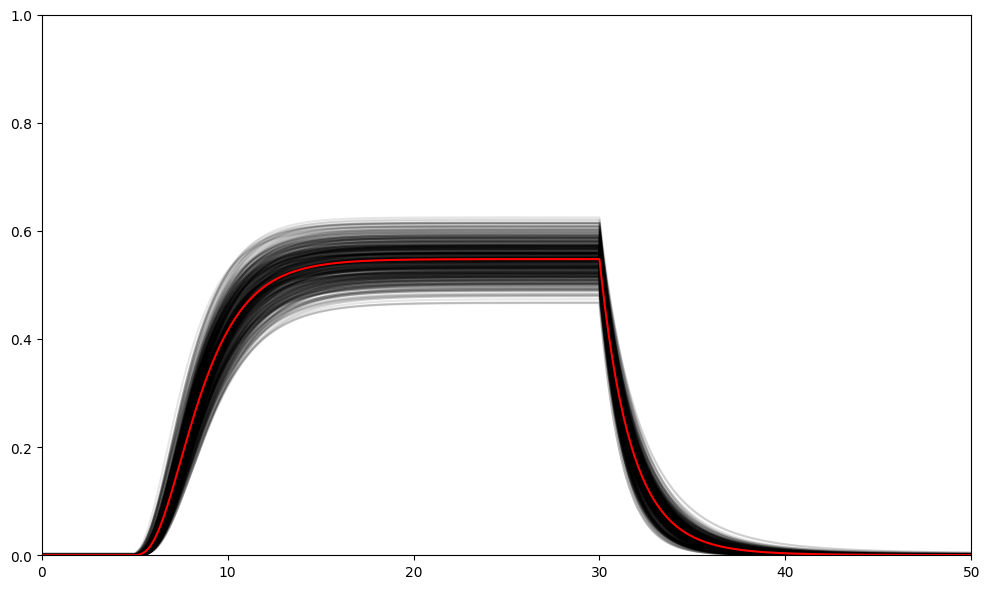


Saving results...
Done!


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# SALib imports
from SALib.sample import saltelli
from SALib.analyze import sobol


def simulate_K_conductance(params, t_steps, v_steps, tmax=50.0, dt=0.1):
    """
    Simulate the potassium conductance under a given voltage protocol.
    
    Parameters
    ----------
    params : list or array
        Parameter vector [gbar_K, A_alpha, V_alpha, k_alpha, A_beta, tau_beta]
    t_steps : list or array
        Time points defining the voltage step protocol (e.g. [0.0, 5.0, 30.0])
    v_steps : list or array
        Voltage levels at each step (e.g. [-65.0, 0.0, -65.0])
    tmax : float
        Total simulation time in ms.
    dt : float
        Time step for integration in ms.
    
    Returns
    -------
    time : numpy array
        The time vector for the simulation.
    g_trace : numpy array
        The potassium conductance (mS/cm²) at each time step of the simulation.
    """
    # Unpack parameters
    A_alpha, V_alpha, k_alpha, A_beta, tau_beta = params
    
    # Define rate functions
    def alpha_n(V):
        return A_alpha * (V_alpha + V) / (1.0 - np.exp(-(V_alpha + V)/k_alpha))
    
    def beta_n(V):
        return A_beta * np.exp(-V/tau_beta)
    
    def VC(ti, t, v):
        # Piecewise voltage command
        return (v[0]*(ti >= t[0]) +
                (v[1]-v[0])*(ti >= t[1]) +
                (v[2]-v[1])*(ti >= t[2]))
    
    def dn_dt(n, ti):
        V = VC(ti, t_steps, v_steps)
        return alpha_n(V)*(1.0 - n) - beta_n(V)*n
    
    # Time vector
    time = np.arange(0, tmax+dt, dt)

    # Initial condition for n (steady state at initial holding voltage)
    V_hold = VC(0, t_steps, v_steps)
    alpha_init = alpha_n(V_hold)
    beta_init  = beta_n(V_hold)
    n_inf_init = alpha_init / (alpha_init + beta_init)
    n0 = n_inf_init

    # Solve the ODE
    solution = odeint(dn_dt, n0, time)
    n_trace = solution[:, 0]

    # Compute conductance: g_K(t) = gbar_K * n^4
    g_trace = n_trace**4
    
    return time, g_trace


if __name__ == "__main__":
    # Base parameters (mean values)
    params = np.array([0.0092, 59, 6.9, 0.066, 100])
    
    # Standard deviations
    std = np.array([0.0004, 2.8, 1.8, 0.003, 13.5])

    # Define voltage protocol
    t_steps = [0.0, 5.0, 30.0]
    v_steps = [-80.0, -10.0, -80.0]

    # Define parameter ranges as mean ± 2*std (uniform distribution)
    low = params - 2*std
    low = np.maximum(low, 1e-10)  # Ensure no negative values
    high = params + 2*std
    
    print("Parameter bounds (mean ± 2*std):")
    param_names = ['A_alpha', 'V_alpha', 'k_alpha', 'A_beta', 'tau_beta']
    for i, name in enumerate(param_names):
        print(f"  {name}: [{low[i]:.4f}, {high[i]:.4f}] (mean={params[i]:.4f})")

    # Define the SALib problem with uniform bounds
    problem = {
        'num_vars': 5,
        'names': param_names,
        'bounds': list(zip(low, high))
    }

    # Generate Saltelli samples (uniform distribution)
    N = 8192 #4096  # Number of samples
    print(f"\nGenerating {N} Saltelli samples...")
    param_values = saltelli.sample(problem, N, calc_second_order=True)
    print(f"Total parameter sets to simulate: {len(param_values)}")

    # Simulate for each parameter set and store the full conductance traces
    # We'll store all results in a 2D array: rows = samples, cols = time points
    time_test, _ = simulate_K_conductance(params, t_steps, v_steps)  # to get time vector
    all_g = np.zeros((len(param_values), len(time_test)))

    print(f"\nRunning {len(param_values)} simulations...")
    for i, X in enumerate(param_values):
        _, g_trace = simulate_K_conductance(X, t_steps, v_steps, tmax=time_test[-1], dt=time_test[1]-time_test[0])
        all_g[i, :] = g_trace

    # We now have all_g: shape (num_samples, num_time_points)
    # Perform Sobol analysis at each time point
    # Y(t) = g(t) for each parameter set
    S1_time = np.zeros((len(time_test), problem['num_vars']))
    S1_conf_time = np.zeros((len(time_test), problem['num_vars']))
    ST_time = np.zeros((len(time_test), problem['num_vars']))

    # Run Sobol analysis for each time step
    print("\nComputing Sobol indices...")
    for ti in range(len(time_test)):
        Y_t = all_g[:, ti]
        Si = sobol.analyze(problem, Y_t, print_to_console=False)
        S1_time[ti, :] = Si['S1']
        S1_conf_time[ti, :] = Si['S1_conf']
        ST_time[ti, :] = Si['ST']

    # Plot the first-order Sobol indices as a function of time
    print("\nGenerating plots...")
    plt.figure(figsize=(10,6))
    for p in range(problem['num_vars']):
        plt.plot(time_test, S1_time[:, p], label=param_names[p])

    plt.xlabel('Time (ms)')
    plt.ylabel('First-Order Sobol Index')
    plt.title('Sobol First-Order Indices over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()


# (Optional) Plot total-order indices
    plt.figure(figsize=(10, 6))
    for p in range(problem['num_vars']):
        plt.plot(time_test, ST_time[:, p], label=param_names[p])
    plt.xlabel('Time (ms)')
    plt.ylabel('ST Index')
    plt.title('Time-Dependent Total-Order Sobol Sensitivity')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#plot the potasium conductance as a function of time
    plt.figure(figsize=(10, 6))  # Convert cm to inches
    plt.xlim(0, time_test[-1])
    plt.ylim(0, 1)
    
    for i in range(500):
        plt.plot(time_test, all_g[i], 'k', alpha=0.1)
    print(len(all_g))
    #add the mean conductance to the graph in red color
    plt.plot(time_test, np.mean(all_g, axis=0), 'r')
    plt.tight_layout()
    plt.show()
    #save the figure as a postscript file
    plt.savefig('g_k_time.eps', format='eps')


    # SAVE THE DATA to csv files
    print("\nSaving results...")
    np.savetxt('all_g_k.csv', all_g[:500], delimiter=',')
    header = ','.join(param_names)
    np.savetxt('S1_time_k.csv', S1_time, delimiter=',', header=header, comments='')
    np.savetxt('ST_time_k.csv', ST_time, delimiter=',', header=header, comments='')
    np.savetxt('S1_conf_time_k.csv', S1_conf_time, delimiter=',', header=header, comments='')
    np.savetxt("mean_activation_gate_n.csv", np.mean(all_g, axis=0), delimiter=',')
    print("Done!")


In [10]:
np.savetxt('Tall_g_k.csv', all_g[:500].T, delimiter=',')